In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import binom
from fractions import Fraction

from matplotlib.colors import LinearSegmentedColormap, PowerNorm, LogNorm

import matplotlib.animation as animation
from IPython.display import HTML
plt.rcParams["animation.embed_limit"] = 800  # MB, raised from the 20 MB default

from tenpy.networks import site
from tenpy.networks.mps import MPS
from tenpy.networks.mps import MPSEnvironment
from tenpy.models.model import CouplingMPOModel
from tenpy.models.lattice import Chain
from tenpy.algorithms import dmrg, tdvp

In [4]:
class SpinModel(CouplingMPOModel):

    default_lattice = 'Chain'
    force_default_lattice = True

    def init_params(self, model_params):

        S = model_params.get('S', 1/2)

        sites = site.SpinSite(S=S, conserve=None)

        return sites

    def init_lattice(self, model_params):

        L = model_params.get('L', 10)

        bc_MPS = model_params.get('bc_MPS', 'finite')
        bc = model_params.get('bc', 'open')

        lattice = Chain(L, site=self.init_params(model_params), bc=bc)

        return lattice

    def init_terms(self, model_params):

        Jx = model_params.get('Jx', 1.0)
        Jy = model_params.get('Jy', 0.0)
        Jz = model_params.get('Jz', 0.0)

        Ax = model_params.get('Ax', 0.0)
        Ay = model_params.get('Ay', 0.0)
        Az = model_params.get('Az', 0.0)

        Nx = model_params.get('Nx', 0.0)
        Ny = model_params.get('Ny', 0.0)
        Nz = model_params.get('Nz', 0.0)

        hx = model_params.get('hx', 0.0)
        hz = model_params.get('hz', 0.0)

        for u in range(len(self.lat.unit_cell)):
            self.add_coupling(Jx, u, 'Sx', u, 'Sx', dx=[1])
            self.add_coupling(Jy, u, 'Sy', u, 'Sy', dx=[1])
            self.add_coupling(Jz, u, 'Sz', u, 'Sz', dx=[1]) 

        for u in range(len(self.lat.unit_cell)):
            self.add_coupling(Nx, u, 'Sx', u, 'Sx', dx=[2])
            self.add_coupling(Ny, u, 'Sy', u, 'Sy', dx=[2])
            self.add_coupling(Nz, u, 'Sz', u, 'Sz', dx=[2])

        self.add_onsite(Ax, 0, 'Sx Sx')
        self.add_onsite(Ay, 0, 'Sy Sy')
        self.add_onsite(Az, 0, 'Sz Sz')

        self.add_onsite(hx, 0, 'Sx')
        self.add_onsite(hz, 0, 'Sz')


In [10]:
def simulation(psi, site, S, model, times, tdvp_params, N_theta=25, N_phi=50):

    psi = psi.copy()

    Paulis = [psi.sites[site].get_op(name).transpose(['p', 'p*']).to_ndarray()
        for name in ('Sx', 'Sy', 'Sz')]

    L = psi.L
    N_t = len(times)

    theta = np.linspace(0, np.pi, N_theta)
    phi = np.linspace(-np.pi, np.pi, N_phi)

    rho = np.zeros((N_t, int(2*S + 1), int(2*S + 1)), dtype=complex)

    Sx = np.zeros(N_t, dtype=complex)
    Sy = np.zeros(N_t, dtype=complex)
    Sz = np.zeros(N_t, dtype=complex)

    Q_avg = np.zeros((N_theta, N_phi), dtype=complex)

    tdvp_engine = tdvp.TwoSiteTDVPEngine(psi, model, tdvp_params)

    print(f"Computing Husimi Q-function and trajectories for S={S} at site {site} ")

    for ti, t in enumerate(times):

        rho[ti] = psi.get_rho_segment([site]).transpose(['p0', 'p0*']).to_ndarray()

        tdvp_engine.run()

        if (ti + 1) % max(1, N_t // 10) == 0 or ti == N_t - 1:
            print(f"Time step {ti+1}/{N_t} ... ")

    Sx, Sy, Sz = (np.trace(rho @ P, axis1=1, axis2=2) for P in Paulis)

    rho_avg = np.mean(rho, axis=0)

    for i, th in enumerate(theta):
        for j, ph in enumerate(phi):

            c_m = coherent_state(S, th, ph)

            Q_avg[i, j] = c_m.conj().T @ rho_avg @ c_m

    print(f"Sanity check: \n Tr(rho_avg) = {np.trace(rho_avg):.6f} \n Im(Q_avg) = {np.max(Q_avg.imag):.6f}")

    print()
    print("="*50)

    return Q_avg.real, Sx, Sy, Sz


def spectral(psi, model, times):

    L = psi.L

    ket = psi.copy()
    bra = psi.copy()

    ket.apply_local_op(L//2, 'Sz')

    eng_ket = tdvp.TwoSiteTDVPEngine(ket, model, tdvp_params)
    eng_bra = tdvp.TwoSiteTDVPEngine(bra, model, tdvp_params)
    
    C = np.zeros((len(times), L), dtype=complex)

    C[0] = MPSEnvironment(bra, ket).expectation_value('Sz')

    for ti, t in enumerate(times):

        eng_bra.run()
        eng_ket.run()

        C[ti] = MPSEnvironment(bra, ket).expectation_value('Sz')

    return C

def coherent_state(S, theta, phi):

    """ 
    This function requires a derivation to understand!
    
    |S,S> is the state pointing along +z. To make it point along
        
        n = (sin(theta)cos(phi), sin(theta)sin(phi), cos(theta))
    
    we rotate by theta about the axis perpendicular to both z and n,
        
        m = z x n / |z x n| = (-sin(phi), cos(phi), 0),
    
    i.e.
    
            |theta, phi> = exp(-i * theta * m . S) |S,S>.

    The coefficients c_m are then found by expanding this exponential.
    """

    m = np.arange(-S, S + 1)                      

    c_m = (np.sqrt(binom(2 * S, S + m))
         * np.cos(theta / 2) ** (S + m)
         * np.sin(theta / 2) ** (S - m)
         * np.exp(-1j * m * phi))
    
    return c_m / np.linalg.norm(c_m)    

In [ ]:
N_theta = 60
N_phi = 60

L = 2 
S = [1/2, 1]

Jx= np.pi
Jy= np.e
Jz= (1 + np.sqrt(5)) / 2

Ax = np.sqrt(3)
Ay = np.sqrt(2)
Az = np.sqrt(5) 

Nx = 0.0
Ny = 0.0
Nz = 0.0

hx = 0.0
hz = 0.0

N_t = 10000
t_max = 100
times = np.linspace(0, t_max, N_t)

tdvp_params = {
    'N_steps': 1,
    'dt': times[1] - times[0],
    'trunc_params': {
        'chi_max': 100, 
        'svd_min': 1.e-6,
    },
}

Sx = np.zeros((len(S), L, N_t), dtype=complex)
Sy = np.zeros((len(S), L, N_t), dtype=complex)
Sz = np.zeros((len(S), L, N_t), dtype=complex)

Q_avg = np.zeros((len(S), L, N_theta, N_phi), dtype=float)

for si, S_i in enumerate(S):
    for site_idx in range(L):
        
        model_params = {
            'L': L,
            'S': S_i,
            'Jx': Jx, 'Jy': Jy, 'Jz': Jz,
            'Ax': Ax, 'Ay': Ay, 'Az': Az,
            'Nx': Nx, 'Ny': Ny, 'Nz': Nz,
            'hx': hx, 'hz': hz,
        }

        model = SpinModel(model_params)

        rng = np.random.default_rng(seed=42)

        theta0 = np.pi / 4
        phi0 = np.pi / 3

        eps = 0.1

        theta = theta0 + rng.uniform(-eps, eps, L)
        phi = phi0 + rng.uniform(-eps, eps, L)

        psi0 = [coherent_state(S_i, theta[i], phi[i]) for i in range(L)]

        psi = MPS.from_product_state(model.lat.mps_sites(), psi0, bc=model.lat.bc_MPS, dtype=complex)

        Q_avg[si, site_idx], Sx[si, site_idx], Sy[si, site_idx], Sz[si, site_idx] = simulation(psi, site_idx, S_i, model, times, tdvp_params, N_theta=N_theta, N_phi=N_phi)    
    
print()
print("Simulation complete!")

Computing Husimi Q-function and trajectories for S=0.5 at site 0 
Time step 1000/10000 ... 
Time step 2000/10000 ... 
Time step 3000/10000 ... 
Time step 4000/10000 ... 
Time step 5000/10000 ... 
Time step 6000/10000 ... 
Time step 7000/10000 ... 
Time step 8000/10000 ... 
Time step 9000/10000 ... 
Time step 10000/10000 ... 
Sanity check: 
 Tr(rho_avg) = 1.000000+0.000000j 
 Im(Q_avg) = 0.000000

Computing Husimi Q-function and trajectories for S=0.5 at site 1 
Time step 1000/10000 ... 
Time step 2000/10000 ... 
Time step 3000/10000 ... 
Time step 4000/10000 ... 
Time step 5000/10000 ... 
Time step 6000/10000 ... 
Time step 7000/10000 ... 
Time step 8000/10000 ... 
Time step 9000/10000 ... 
Time step 10000/10000 ... 
Sanity check: 
 Tr(rho_avg) = 1.000000-0.000000j 
 Im(Q_avg) = 0.000000

Computing Husimi Q-function and trajectories for S=1 at site 0 
Time step 1000/10000 ... 
Time step 2000/10000 ... 
Time step 3000/10000 ... 
Time step 4000/10000 ... 
Time step 5000/10000 ... 
Time s

In [ ]:
np.savez_compressed(
    f"husimi_L{L}_J{Jx:.3f}_{Jy:.3f}_{Jz:.3f}_A{Ax:.3f}_{Ay:.3f}_{Az:.3f}.npz",
    Q=Q_avg.astype(np.float32), Sx=Sx, Sy=Sy, Sz=Sz,
    spin=np.array(S), L=L, times=times,
    N_theta=N_theta, N_phi=N_phi,
    Jx=Jx, Jy=Jy, Jz=Jz,
    Ax=Ax, Ay=Ay, Az=Az,
)


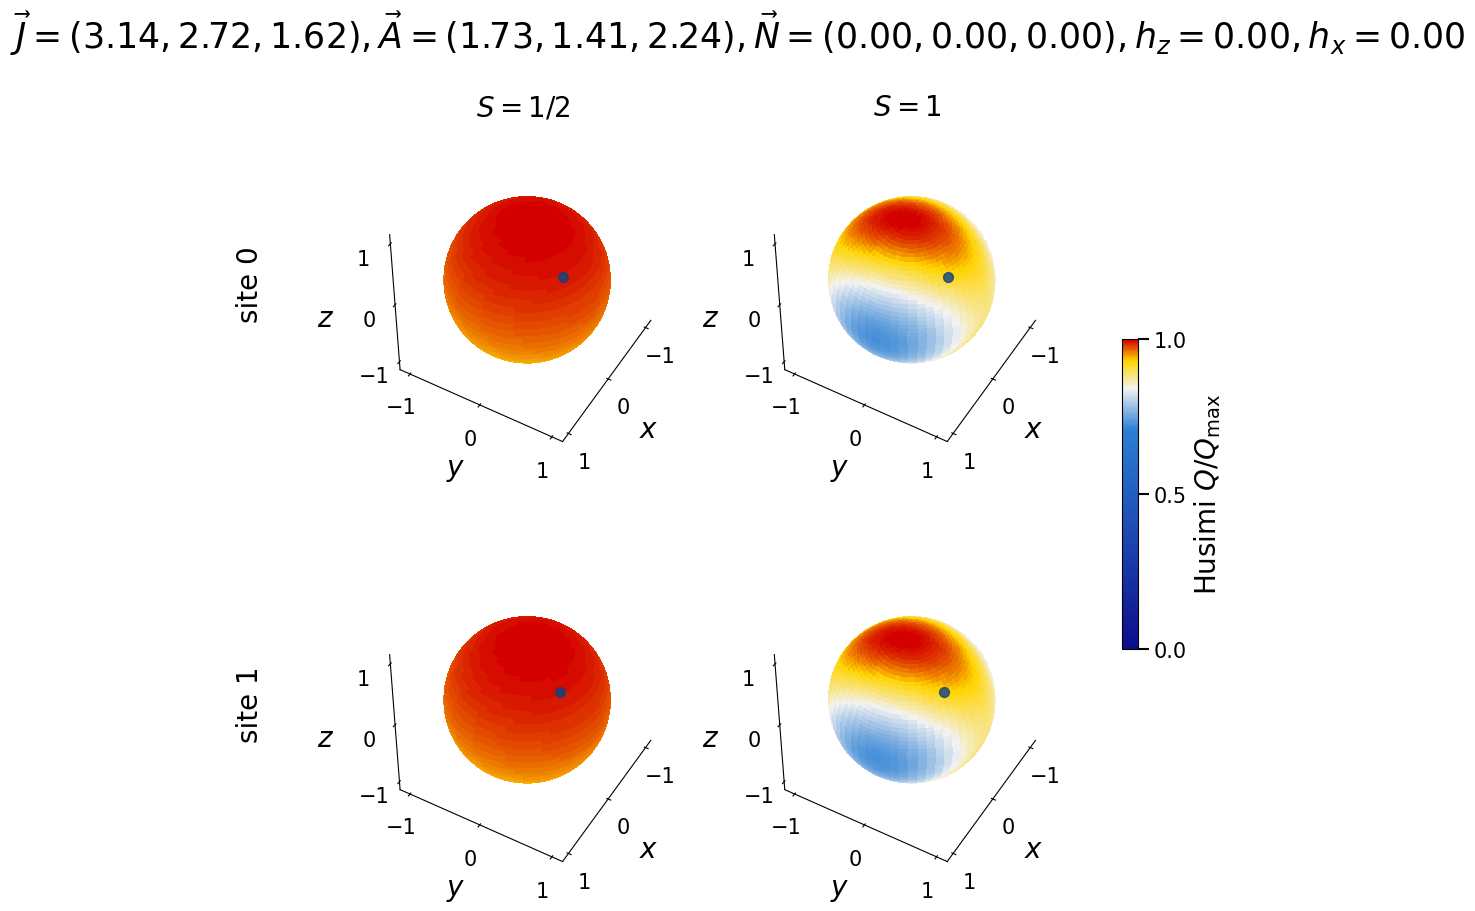

In [16]:
elev, azim, roll = 45, 30, None

el, az = np.radians(elev), np.radians(azim)
eye = np.array([np.cos(el) * np.cos(az), np.cos(el) * np.sin(az), np.sin(el)])

trajectory = False
quiver = False
initial_condition = True

#cmap = LinearSegmentedColormap.from_list('husimi', ["#0d0d8c", "#2b7fd4", "#f2f2f2", "#ffd400", "#d40000"])

N_color = 256
x_color = np.linspace(0, 1, 256)
scale = x_color**(1/4)

cmap = LinearSegmentedColormap.from_list('husimi', [
    (scale[0], "#0d0d8c"),
    (scale[N_color // 4], "#2b7fd4"),
    (scale[N_color // 2], "#f2f2f2"),
    (scale[3 * N_color // 4], "#ffd400"),
    (scale[-1], "#d40000"),
])


theta, phi = np.meshgrid(np.linspace(0, np.pi, N_theta), np.linspace(-np.pi, np.pi, N_phi), indexing='ij')

x, y, z = np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)

fig, axes = plt.subplots(L, len(S), figsize=(5 * len(S), 5 * L), 
                subplot_kw={'projection': '3d', 'computed_zorder': False})

fig.suptitle(rf"$\vec{{J}} = ({Jx:.2f}, {Jy:.2f}, {Jz:.2f}), \vec{{A}} = ({Ax:.2f}, {Ay:.2f}, {Az:.2f}), \vec{{N}} = ({Nx:.2f}, {Ny:.2f}, {Nz:.2f}), h_z = {hz:.2f}, h_x = {hx:.2f}$", fontsize=25)

for si, S_i in enumerate(S):
    for site_idx in range(L):

        nx, ny, nz = Sx[si, site_idx].real.T / S_i, Sy[si, site_idx].real.T / S_i, Sz[si, site_idx].real.T / S_i

        norm = np.sqrt(nx**2 + ny**2 + nz**2)
        
        nx, ny, nz = nx / norm, ny / norm, nz / norm

        ax = axes[site_idx, si] if L > 1 else axes[si]

        Qn = Q_avg[si, site_idx] / Q_avg[si, site_idx].max()

        ax.plot_surface(x, y, z, facecolors=cmap(Qn), rstride=1, cstride=1,
                        shade=False, linewidth=0, antialiased=False, zorder=1)

        if trajectory==True:
            front = nx * eye[0] + ny * eye[1] + nz * eye[2] > 0

            ax.plot(np.where(front, nx, np.nan),
                    np.where(front, ny, np.nan),
                    np.where(front, nz, np.nan),
                    color="#2a78d6", lw=2, zorder=2, alpha=0.5)   

        if initial_condition==True:
            ax.scatter(nx[0] / norm[0], ny[0] / norm[0], nz[0] / norm[0], color="#104281", s=50, marker='o', alpha=0.8, zorder=2)

        nbar = np.array([np.mean(nx), np.mean(ny), np.mean(nz)])
        nbar = nbar / np.linalg.norm(nbar)

        if quiver==True:
            ax.quiver(*nbar, *(0.45*nbar), color="#104281", lw=2,
                      arrow_length_ratio=0.5, zorder=8)


        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)

        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_zticks([-1, 0, 1])

        ax.set_xlabel(r"$x$", fontsize=20, labelpad=10)
        ax.set_ylabel(r"$y$", fontsize=20, labelpad=10)
        ax.set_zlabel(r"$z$", fontsize=20, labelpad=10)

        ax.tick_params(labelsize=15)

        ax.grid(False)
        ax.set_box_aspect([1, 1, 1])   
        ax.view_init(elev=elev, azim=azim, roll=roll) 

        if site_idx == 0:
            ax.set_title(rf"$S = {Fraction(S[si]).limit_denominator(2)}$", fontsize=20)
        if si == 0:
            ax.text2D(-0.35, 0.5, f"site {site_idx}", transform=ax.transAxes,
                      rotation=90, va='center', ha='center', fontsize=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=axes, location='right',
                    fraction=0.02, pad=0.07, shrink=0.6, ticks=[0, 0.5, 1])
cbar.set_label(r"Husimi $Q/Q_{\max}$", fontsize=20)
cbar.ax.tick_params(length=8, width=1.5, labelsize=15)

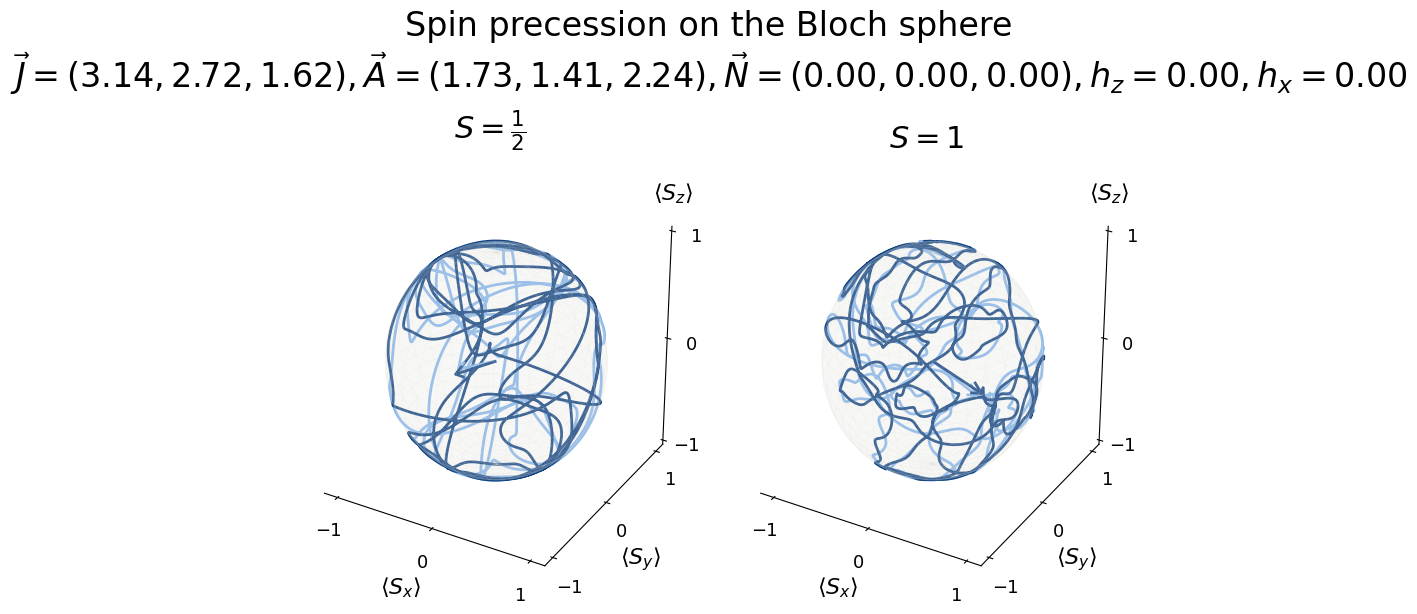

In [13]:
t_idx = -1        # time index at which the L instantaneous vectors are drawn
Normalize = True

fig, axes = plt.subplots(1, len(S), figsize=(4.5 * len(S), 5.5),
                         subplot_kw={"projection": "3d"})
fig.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02, wspace=0.02)

# reference sphere, shared by every panel
theta_s, phi_s = np.mgrid[0:2 * np.pi:60j, 0:np.pi:30j]
x, y, z = np.cos(theta_s) * np.sin(phi_s), np.sin(theta_s) * np.sin(phi_s), np.cos(phi_s)

# sequential "blue" ramp, light -> dark (ordinal-safe range: step 250 -> 650)
blue_ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
blue_cmap = LinearSegmentedColormap.from_list("blue_seq", blue_ramp)
colors = [blue_cmap(i / max(L - 1, 1)) for i in range(L)]

for si, s in enumerate(S):

    ax = axes[si]

    # Bloch vectors n = <S>/S: unit sphere for a pure, unentangled site;
    # |n| < 1 once the site becomes entangled with the rest of the chain.
    nx, ny, nz = Sx[si].real.T / s, Sy[si].real.T / s, Sz[si].real.T / s


    if Normalize == True:
        # normalize the Bloch vectors to have unit length for visualization
        norms = np.sqrt(nx**2 + ny**2 + nz**2)
        nx = nx / norms
        ny = ny / norms
        nz = nz / norms

    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)

    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_zticks([-1, 0, 1])

    ax.tick_params(labelsize=13)

    # same data-coordinate placement as plots.bloch: unlike set_zlabel, these
    # project inside the panel instead of being clipped past its right edge
    ax.text(0.0, -2.0, -1.2, r"$\langle S_x\rangle$", fontsize=16)
    ax.text(1.3, 0.0, -1.6, r"$\langle S_y\rangle$", fontsize=16)
    ax.text(1.5, 0.0, 1.8, r"$\langle S_z\rangle$", fontsize=16)

    ax.grid(False)
    ax.set_box_aspect([1, 1, 1])

    # spin as a fraction: 1/2 -> \frac{1}{2}, 2 -> 2
    frac = Fraction(s).limit_denominator(2)
    s_label = (f"{frac.numerator}" if frac.denominator == 1
               else rf"\frac{{{frac.numerator}}}{{{frac.denominator}}}")
    ax.set_title(rf"$S = {s_label}$", fontsize=22, pad=0)

    ax.plot_surface(x, y, z, color="#e1e0d9", alpha=0.12, linewidth=0, shade=False)
    ax.plot_wireframe(x, y, z, color="#e1e0d9", alpha=0.25, linewidth=0.3)

    for site_idx in range(L):
        color = colors[site_idx]
        # trajectory of this site's Bloch vector over the whole time evolution
        ax.plot(nx[:, site_idx], ny[:, site_idx], nz[:, site_idx], color=color, lw=2)
        # instantaneous vector at t_idx
        ax.quiver(0, 0, 0, nx[t_idx, site_idx], ny[t_idx, site_idx], nz[t_idx, site_idx],
                  color=color, linewidth=2, arrow_length_ratio=0.2)

fig.suptitle(r"Spin precession on the Bloch sphere" + "\n" + rf"$\vec{{J}} = ({Jx:.2f}, {Jy:.2f}, {Jz:.2f}), \vec{{A}} = ({Ax:.2f}, {Ay:.2f}, {Az:.2f}), \vec{{N}} = ({Nx:.2f}, {Ny:.2f}, {Nz:.2f}), h_z = {hz:.2f}, h_x = {hx:.2f}$", fontsize=24, y=1.1)

plt.show()